# 新闻主题建模：预处理、LDA 与 LSA

本文件依次完成依赖准备、数据检查、文本预处理、词袋构建、LDA 分析与可视化，以及 LSA 的 2～10 主题筛选。两种模型共用 `processed_documents` 和词典：LDA 使用词频，LSA 使用 TF-IDF。主要参数集中在第 1 节，修改后建议重启内核并按顺序运行全部单元。

处理对象为英文正文 `content`，保留原始标题和正文。为匹配英文停用词，先统一小写。删除停用词依赖单词边界，因此实际顺序为：去标点 → 分词 → 删除停用词 → 词干提取。

## 1. 准备依赖

当前环境已安装所需库。如果切换到新环境，可在代码单元运行 `%pip install nltk gensim pandas`，随后重启内核。英文停用词资源缺失时，下面的代码会尝试下载。

In [1]:
from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk
import gensim
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, LdaModel, LsiModel, TfidfModel
from matplotlib.ticker import MaxNLocator, PercentFormatter
from nltk.corpus import stopwords
from nltk.tokenize import WhitespaceTokenizer
from nltk.stem import PorterStemmer
from IPython.display import display

# 修改参数后建议使用“Restart Kernel and Run All”，避免旧模型与新参数混用。
CSV_FILENAME = "news_articles.csv"
TEXT_COLUMN = "content"
PREVIEW_ROWS = 5
RESULT_PREVIEW_ROWS = 10
TOP_WORDS = 10  # 两种模型统一展示/评价的关键词数量。
RANDOM_SEED = 42  # 固定随机种子，便于复现实验结果。
LDA_NUM_TOPICS = 5
LDA_PASSES = 20  # 完整遍历训练语料的次数。
LDA_ITERATIONS = 100  # 每篇文档推断的最大迭代次数。
LSA_TOPIC_COUNTS = list(range(2, 11))
REPRESENTATIVE_NEWS_COUNT = 3
PLOT_COLOR = "#2563EB"
HIGHLIGHT_COLOR = "#D97706"

print(f"NLTK: {nltk.__version__}")
print(f"Gensim: {gensim.__version__}")
print(f"pandas: {pd.__version__}")

# 只在本机缺少资源时下载；分词器和词干提取器无需下载额外模型。
try:
    STOP_WORDS = set(stopwords.words("english"))
except LookupError:
    if not nltk.download("stopwords", quiet=False):
        raise RuntimeError("英文停用词下载失败，请检查网络后重试。")
    STOP_WORDS = set(stopwords.words("english"))

tokenizer = WhitespaceTokenizer()
stemmer = PorterStemmer()
print(f"英文停用词数量：{len(STOP_WORDS)}")
print("停用词示例：", sorted(STOP_WORDS)[:20])

NLTK: 3.10.3
Gensim: 4.4.0
pandas: 3.0.5
英文停用词数量：198
停用词示例： ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


## 2. 读取并检查新闻数据

展示前 5 行、字段类型、缺失值和重复记录数量。正文预览限制显示宽度，原始数据不会被截断。

In [2]:
# 兼容从 notebook 所在目录或课程根目录启动内核。
csv_candidates = [
    Path.cwd() / CSV_FILENAME,
    Path.cwd() / "25_NLP模块主题建模" / CSV_FILENAME,
]
csv_path = next((path for path in csv_candidates if path.is_file()), None)
if csv_path is None:
    raise FileNotFoundError(f"找不到 {CSV_FILENAME}，当前目录为 {Path.cwd()}")

news = pd.read_csv(csv_path, encoding="utf-8")
# 标题和 ID 也用于后续结果展示，读取时一次性检查全部必要字段。
required_columns = {"id", "title", TEXT_COLUMN}
missing_columns = required_columns.difference(news.columns)
if missing_columns:
    raise ValueError(f"缺少字段：{sorted(missing_columns)}")
news[TEXT_COLUMN] = news[TEXT_COLUMN].astype("string")

print(f"数据文件：{csv_path.resolve()}")
print(f"新闻数量：{len(news)}；字段数量：{len(news.columns)}")
with pd.option_context("display.max_colwidth", 120):
    display(news.head(PREVIEW_ROWS))

display(pd.DataFrame({
    "字段类型": news.dtypes.astype(str),
    "缺失数量": news.isna().sum(),
}))
print(f"完全重复的记录数：{news.duplicated().sum()}")
print(f"重复正文数：{news[TEXT_COLUMN].duplicated().sum()}")

数据文件：D:\Study\AI_Study\Course1_365\25_NLP模块主题建模\news_articles.csv
新闻数量：100；字段数量：3


,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Even Close - The New York Times","Dr. Frank Sacks, a professor of nutrition at Harvard, likes to challenge his audience when he gives lectures on obes..."
1,19551,South Carolina Stuns Baylor to Reach the Round of Eight - The New York Times,"South Carolina’s win over Duke was not only a surprise to fans. In the postgame revelry, Coach Frank Martin had to..."
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Your Tuesday Evening Briefing - The New York Times",(Want to get this briefing by email? Here’s the .) Good evening. Here’s the latest. 1. One of the Islamic State’s m...
3,18026,"His Predecessor Gone, Gambia’s New President Finally Comes Home - The New York Times","BANJUL, Gambia — A week after he was inaugurated in another country, Adama Barrow landed in Gambia on Thursday af..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From Stage to Page on Saturday at the Witching Hour - The New York Times,The biggest book of the summer isn’t a blockbuster thriller or a splashy celebrity memoir. It’s a play about a wiz...


,字段类型,缺失数量
id,int64,0
title,str,0
content,string,0


完全重复的记录数：0
重复正文数：0


## 3. 去标点、分词、删除停用词、词干提取

使用 Unicode 标点类别识别英文引号、弯引号和破折号等标点，并替换为空格，避免相邻单词粘连。保留数字与其他非标点字符；停用词采用 NLTK 英文词表。

Porter 词干提取将词语的不同形式缩减为词干，例如 `playing → play`。词干可能不是完整英文单词，这是算法的正常结果。

In [3]:
def remove_punctuation(text: str) -> str:
    """统一小写、将 Unicode 标点替换为空格，并合并多余空白。"""
    lowercase_text = text.lower()
    without_punctuation = "".join(
        " " if unicodedata.category(character).startswith("P") else character
        for character in lowercase_text
    )
    return " ".join(without_punctuation.split())


def remove_stopwords(tokens: list[str]) -> list[str]:
    """按完整单词过滤停用词，避免误删其他单词中的字符。"""
    return [token for token in tokens if token not in STOP_WORDS]


def stem_tokens(tokens: list[str]) -> list[str]:
    """逐词进行 Porter 词干提取，返回列表供后续主题建模使用。"""
    return [stemmer.stem(token) for token in tokens]


# 在副本中处理，保留 news 和原始 content，便于学习时对照。
valid_text = news[TEXT_COLUMN].fillna("").str.strip().ne("")
print(f"空正文记录数：{int((~valid_text).sum())}")
news_processed = news.loc[valid_text].copy()

news_processed["text_no_punctuation"] = news_processed[TEXT_COLUMN].apply(remove_punctuation)
news_processed["tokens"] = news_processed["text_no_punctuation"].apply(tokenizer.tokenize)
news_processed["tokens_no_stopwords"] = news_processed["tokens"].apply(remove_stopwords)
news_processed["stemmed_tokens"] = news_processed["tokens_no_stopwords"].apply(stem_tokens)

with pd.option_context("display.max_colwidth", 100):
    display(news_processed[[
        "title", "text_no_punctuation", "tokens",
        "tokens_no_stopwords", "stemmed_tokens",
    ]].head(PREVIEW_ROWS))

空正文记录数：0


,title,text_no_punctuation,tokens,tokens_no_stopwords,stemmed_tokens
0,"One Weight-Loss Approach Fits All? No, Not Even Close - The New York Times",dr frank sacks a professor of nutrition at harvard likes to challenge his audience when he gives...,"[dr, frank, sacks, a, professor, of, nutrition, at, harvard, likes, to, challenge, his, audience...","[dr, frank, sacks, professor, nutrition, harvard, likes, challenge, audience, gives, lectures, o...","[dr, frank, sack, professor, nutrit, harvard, like, challeng, audienc, give, lectur, obes, want,..."
1,South Carolina Stuns Baylor to Reach the Round of Eight - The New York Times,south carolina s win over duke was not only a surprise to fans in the postgame revelry coach fra...,"[south, carolina, s, win, over, duke, was, not, only, a, surprise, to, fans, in, the, postgame, ...","[south, carolina, win, duke, surprise, fans, postgame, revelry, coach, frank, martin, ask, assis...","[south, carolina, win, duke, surpris, fan, postgam, revelri, coach, frank, martin, ask, assist, ..."
2,"U.S. Presidential Race, Apple, Gene Wilder: Your Tuesday Evening Briefing - The New York Times",want to get this briefing by email here s the good evening here s the latest 1 one of the islami...,"[want, to, get, this, briefing, by, email, here, s, the, good, evening, here, s, the, latest, 1,...","[want, get, briefing, email, good, evening, latest, 1, one, islamic, state, senior, strategists,...","[want, get, brief, email, good, even, latest, 1, one, islam, state, senior, strategist, abu, muh..."
3,"His Predecessor Gone, Gambia’s New President Finally Comes Home - The New York Times",banjul gambia a week after he was inaugurated in another country adama barrow landed in gambia o...,"[banjul, gambia, a, week, after, he, was, inaugurated, in, another, country, adama, barrow, land...","[banjul, gambia, week, inaugurated, another, country, adama, barrow, landed, gambia, thursday, a...","[banjul, gambia, week, inaugur, anoth, countri, adama, barrow, land, gambia, thursday, afternoon..."
4,‘Harry Potter and the Cursed Child’ Goes From Stage to Page on Saturday at the Witching Hour - T...,the biggest book of the summer isn t a blockbuster thriller or a splashy celebrity memoir it s a...,"[the, biggest, book, of, the, summer, isn, t, a, blockbuster, thriller, or, a, splashy, celebrit...","[biggest, book, summer, blockbuster, thriller, splashy, celebrity, memoir, play, wizard, publica...","[biggest, book, summer, blockbust, thriller, splashi, celebr, memoir, play, wizard, public, harr..."


## 4. 对照中间结果并检查输出

下面展示第一篇新闻在各阶段的前若干词，并汇总处理前后的词数。`processed_documents` 保留每篇非空文档的词干列表，`model_document_indices` 保存对应行索引，便于后续将主题结果关联回新闻。

In [4]:
if not news_processed.empty:
    example = news_processed.iloc[0]
    print("标题：", example["title"])
    print("\n原始正文（前 400 字符）：\n", example[TEXT_COLUMN][:400])
    print("\n去标点后（前 400 字符）：\n", example["text_no_punctuation"][:400])
    print("\n分词（前 30 个）：\n", example["tokens"][:30])
    print("\n删除停用词（前 30 个）：\n", example["tokens_no_stopwords"][:30])
    print("\n词干提取（前 30 个）：\n", example["stemmed_tokens"][:30])

news_processed["token_count"] = news_processed["tokens"].apply(len)
news_processed["filtered_token_count"] = news_processed["tokens_no_stopwords"].apply(len)
news_processed["stemmed_token_count"] = news_processed["stemmed_tokens"].apply(len)

nonempty_documents = news_processed["stemmed_token_count"].gt(0)
model_document_indices = news_processed.index[nonempty_documents].tolist()
processed_documents = news_processed.loc[nonempty_documents, "stemmed_tokens"].tolist()

display(pd.Series({
    "原始新闻数量": len(news),
    "有效正文数量": len(news_processed),
    "分词后总词数": news_processed["token_count"].sum(),
    "删除停用词后总词数": news_processed["filtered_token_count"].sum(),
    "词干提取后总词数": news_processed["stemmed_token_count"].sum(),
    "预处理后空文档数量": int((~nonempty_documents).sum()),
    "后续建模可用文档数量": len(processed_documents),
}, name="数量").to_frame())

# 词干提取只改变词形，不应改变词数；每个文档应保留对应新闻索引。
assert news_processed["filtered_token_count"].equals(news_processed["stemmed_token_count"])
assert len(processed_documents) == len(model_document_indices)
print("预处理完成，可继续使用 processed_documents 进行主题建模。")

标题： One Weight-Loss Approach Fits All? No, Not Even Close - The New York Times

原始正文（前 400 字符）：
 Dr. Frank Sacks, a professor of nutrition at Harvard, likes to challenge his audience when he gives lectures on obesity. “If you want to make a great discovery,” he tells them, figure out this: Why do some people lose 50 pounds on a diet while others on the same diet gain a few pounds? Then he shows them data from a study he did that found exactly that effect. Dr. Sacks’s challenge is a question a

去标点后（前 400 字符）：
 dr frank sacks a professor of nutrition at harvard likes to challenge his audience when he gives lectures on obesity if you want to make a great discovery he tells them figure out this why do some people lose 50 pounds on a diet while others on the same diet gain a few pounds then he shows them data from a study he did that found exactly that effect dr sacks s challenge is a question at the center

分词（前 30 个）：
 ['dr', 'frank', 'sacks', 'a', 'professor', 'of', 'nutrition', 'at', '

,数量
原始新闻数量,100
有效正文数量,100
分词后总词数,111710
删除停用词后总词数,61633
词干提取后总词数,61633
预处理后空文档数量,0
后续建模可用文档数量,100


预处理完成，可继续使用 processed_documents 进行主题建模。


## 5. 构建词袋模型（Bag of Words）

词典为每个词干分配唯一 ID；`doc2bow` 将每篇新闻转换为 `(词 ID, 出现次数)` 列表。词袋保留词频，不保留词序。本次直接使用前面的全部预处理词干，不额外过滤词典，以便理解转换过程。

In [5]:
if not processed_documents:
    raise ValueError("没有可用文档，请先运行并检查预处理单元。")

# 所有新闻共用一个词典，保证同一个词在不同新闻中的 ID 一致。
dictionary = Dictionary(processed_documents)
bow_corpus = [dictionary.doc2bow(document) for document in processed_documents]
if not dictionary:
    raise ValueError("词典为空，无法训练 LDA。")

print(f"文档数量：{len(bow_corpus)}")
print(f"词典词干数量：{len(dictionary)}")
print("第一篇新闻词袋（前 10 项）：", bow_corpus[0][:10])

# 解码词 ID，按出现次数排序，帮助理解稀疏词频表示。
bow_preview = pd.DataFrame(
    [(word_id, dictionary[word_id], count) for word_id, count in bow_corpus[0]],
    columns=["词 ID", "词干", "出现次数"],
).sort_values("出现次数", ascending=False)
print("第一篇新闻中出现次数最多的 20 个词干：")
display(bow_preview.head(20))

# 未过滤词典时，词袋中的次数之和应等于原文档的词干数量。
assert all(
    sum(count for _, count in bow) == len(document)
    for bow, document in zip(bow_corpus, processed_documents)
)

文档数量：100
词典词干数量：8679
第一篇新闻词袋（前 10 项）： [(0, 1), (1, 1), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]
第一篇新闻中出现次数最多的 20 个词干：


,词 ID,词干,出现次数
663,663,weight,52
200,200,dr,36
530,530,said,32
188,188,diet,29
463,463,pound,24
433,433,obes,22
204,204,drug,18
412,412,mr,17
451,451,peopl,15
676,676,would,14


## 6. 使用 Gensim LDA 提取主题

LDA 将每个主题表示为词语的概率分布，将每篇新闻表示为多个主题的混合。先设置 **5 个主题**作为学习起点，并非已经确定的最佳主题数。

`passes` 是遍历整个语料的次数，`iterations` 控制文档推断的最大迭代次数。固定随机种子有助于复现。关键词权重表示词语在该主题中的概率；只展示前 10 个词，因此展示的权重之和通常小于 1。

In [6]:
# 参数统一来自第 1 节；训练使用原始词频。
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=LDA_NUM_TOPICS,
    random_state=RANDOM_SEED,
    passes=LDA_PASSES,
    iterations=LDA_ITERATIONS,
    chunksize=len(bow_corpus),
    alpha="auto",
    eta="auto",
    minimum_probability=0.0,
)

# Gensim 内部编号从 0 开始；展示时统一加 1，便于阅读。
topic_keywords = {
    topic_id: lda_model.show_topic(topic_id, topn=TOP_WORDS)
    for topic_id in range(LDA_NUM_TOPICS)
}
topic_summary = pd.DataFrame([
    {
        "主题": f"主题 {topic_id + 1}",
        "关键词（词干: 权重）": " | ".join(
            f"{word}: {weight:.3f}" for word, weight in words
        ),
    }
    for topic_id, words in topic_keywords.items()
])
with pd.option_context("display.max_colwidth", None):
    display(topic_summary)

,主题,关键词（词干: 权重）
0,主题 1,said: 0.010 | percent: 0.009 | rate: 0.007 | market: 0.005 | year: 0.004 | peopl: 0.004 | like: 0.004 | would: 0.004 | save: 0.004 | student: 0.004
1,主题 2,said: 0.015 | mr: 0.014 | trump: 0.008 | one: 0.006 | ms: 0.005 | weight: 0.005 | peopl: 0.004 | dr: 0.004 | would: 0.004 | new: 0.004
2,主题 3,mr: 0.021 | said: 0.018 | trump: 0.005 | like: 0.005 | would: 0.005 | state: 0.005 | year: 0.004 | one: 0.004 | time: 0.004 | new: 0.004
3,主题 4,said: 0.007 | leas: 0.006 | one: 0.005 | would: 0.004 | book: 0.004 | ms: 0.004 | vehicl: 0.004 | colbert: 0.003 | like: 0.003 | live: 0.003
4,主题 5,mr: 0.022 | said: 0.015 | trump: 0.007 | state: 0.007 | year: 0.004 | would: 0.004 | presid: 0.004 | offici: 0.004 | one: 0.004 | new: 0.003


## 7. 查看新闻主题和代表性文章

每篇新闻可以同时涉及多个主题。下面保留全部主题概率，再用概率最高的主题作为“主要主题”进行统计；这只是便于展示的归类。概率表示模型推断的主题占比，不是准确率。

主题名称需要结合关键词和代表性新闻人工解释。此前做过词干提取，所以关键词中可能出现不完整词形。

In [7]:
# minimum_probability=0.0 保证每篇新闻都返回全部主题，避免小概率项被省略。
document_topic_matrix = np.array([
    [probability for _, probability in sorted(
        lda_model.get_document_topics(bow, minimum_probability=0.0)
    )]
    for bow in bow_corpus
])

assert document_topic_matrix.shape == (len(model_document_indices), LDA_NUM_TOPICS)
assert np.allclose(document_topic_matrix.sum(axis=1), 1.0, atol=1e-5)

topic_columns = [f"主题 {topic_id + 1} 概率" for topic_id in range(LDA_NUM_TOPICS)]
document_topic_probabilities = pd.DataFrame(
    document_topic_matrix,
    index=model_document_indices,
    columns=topic_columns,
)

# 使用原始行索引关联新闻，避免处理过空正文后产生行错位。
news_topic_results = news_processed.loc[model_document_indices, ["id", "title"]].copy()
news_topic_results = news_topic_results.join(document_topic_probabilities)
dominant_topics = document_topic_matrix.argmax(axis=1)
news_topic_results["主要主题"] = [f"主题 {topic_id + 1}" for topic_id in dominant_topics]
news_topic_results["主要主题概率"] = document_topic_matrix.max(axis=1)

with pd.option_context("display.max_colwidth", 90):
    display(news_topic_results.head(RESULT_PREVIEW_ROWS).style.format(
        {column: "{:.1%}" for column in topic_columns + ["主要主题概率"]}
    ))

# 补齐没有成为任何新闻主要主题的类别，防止统计表漏掉主题。
topic_counts = news_topic_results["主要主题"].value_counts().reindex(
    [f"主题 {topic_id + 1}" for topic_id in range(LDA_NUM_TOPICS)], fill_value=0
)
display(topic_counts.rename("主要主题新闻数量").to_frame())
assert topic_counts.sum() == len(bow_corpus)

# 按该主题概率选择代表文章；同一篇新闻可能同时代表多个主题。
for topic_id, probability_column in enumerate(topic_columns):
    print(f"主题 {topic_id + 1}：概率最高的 {REPRESENTATIVE_NEWS_COUNT} 篇新闻")
    representatives = news_topic_results.nlargest(REPRESENTATIVE_NEWS_COUNT, probability_column)
    with pd.option_context("display.max_colwidth", None):
        display(representatives[["id", "title", probability_column]].style.format(
            {probability_column: "{:.1%}"}
        ))


,id,title,主题 1 概率,主题 2 概率,主题 3 概率,主题 4 概率,主题 5 概率,主要主题,主要主题概率
0,25626,"One Weight-Loss Approach Fits All? No, Not Even Close - The New York Times",0.0%,100.0%,0.0%,0.0%,0.0%,主题 2,100.0%
1,19551,South Carolina Stuns Baylor to Reach the Round of Eight - The New York Times,0.0%,100.0%,0.0%,0.0%,0.0%,主题 2,100.0%
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Your Tuesday Evening Briefing - The New York Times",0.0%,0.0%,0.0%,0.0%,100.0%,主题 5,100.0%
3,18026,"His Predecessor Gone, Gambia’s New President Finally Comes Home - The New York Times",0.0%,0.0%,0.0%,0.0%,100.0%,主题 5,100.0%
4,21063,‘Harry Potter and the Cursed Child’ Goes From Stage to Page on Saturday at the Witching Hour - The New York Times,0.0%,0.0%,0.0%,100.0%,0.0%,主题 4,100.0%
5,23141,"Ted Cruz Names Carly Fiorina as His Running Mate, Seeking a Jolt - The New York Times",0.0%,0.0%,82.5%,0.0%,17.5%,主题 3,82.5%
6,17295,"Mar-a-Lago, the Future Winter White House and Home of the Calmer Trump - The New York Times",0.0%,0.0%,0.0%,0.0%,100.0%,主题 5,100.0%
7,22749,Taylor Swift Releases a Surprise Single With Zayn Malik - The New York Times,0.0%,41.7%,58.3%,0.0%,0.0%,主题 3,58.3%
8,20453,"Why Donald Trump, Not Paul Ryan, Is Setting the G.O.P. Agenda - The New York Times",0.0%,100.0%,0.0%,0.0%,0.0%,主题 2,100.0%
9,25918,Spokesman’s Death Will Have Islamic State Turning to Its ‘Deep Bench’ - The New York Times,0.0%,0.0%,0.0%,0.0%,100.0%,主题 5,100.0%


,主要主题新闻数量
主要主题,
主题 1,6
主题 2,17
主题 3,32
主题 4,10
主题 5,35


主题 1：概率最高的 3 篇新闻


,id,title,主题 1 概率
37,21216,Off to College? Maybe These Devices Should Go Along - The New York Times,100.0%
74,20024,Getting Workers to Save More for Retirement - The New York Times,100.0%
43,21140,"A Coup, Terrorists and Inflation, Yet Investors Rush to Turkey - The New York Times",100.0%


主题 2：概率最高的 3 篇新闻


...

,id,title,主题 3 概率
31,19388,"The Battle of ‘Miss Saigon’: Yellowface, Art and Opportunity - The New York Times",100.0%
75,19534,John Mayer Knows He Messed Up. He Wants Another Chance. - The New York Times,100.0%
81,22364,"Mose Allison, a Fount of Jazz and Blues, Dies at 89 - The New York Times",100.0%


主题 4：概率最高的 3 篇新闻


,id,title,主题 4 概率
51,20432,Travel: Philip Marsden’s ‘Rising Ground’ and More - The New York Times,100.0%
92,24267,"Haitians, Battered by Hurricane, Huddle in Caves: ‘This Is the Only Shelter We Have’ - The New York Times",100.0%
34,19114,Let the Lessee Beware: Car Leases Can Be the Most Binding of Contracts - The New York Times,100.0%


主题 5：概率最高的 3 篇新闻


,id,title,主题 5 概率
46,22681,"Saudis Bankroll Taliban, Even as King Officially Supports Afghan Government - The New York Times",100.0%
55,23537,A Surly Misfit With No Terror Links Turned a Truck Into a Tank - The New York Times,100.0%
62,24785,"H.I.V. Cases Surpass a Million in Russia, but Little Is Done - The New York Times",100.0%


### LDA 结果可视化

第一张图按每篇新闻概率最高的主题统计数量，柱顶显示数量和占比。每篇新闻只计入一个主要主题。

第二组图展示各主题的前 10 个关键词及其概率，所有子图使用相同横轴范围，便于比较。关键词经过词干提取，可能不是完整英文单词；显示的前 10 个词不包含整个词典，所以概率之和不等于 100%。

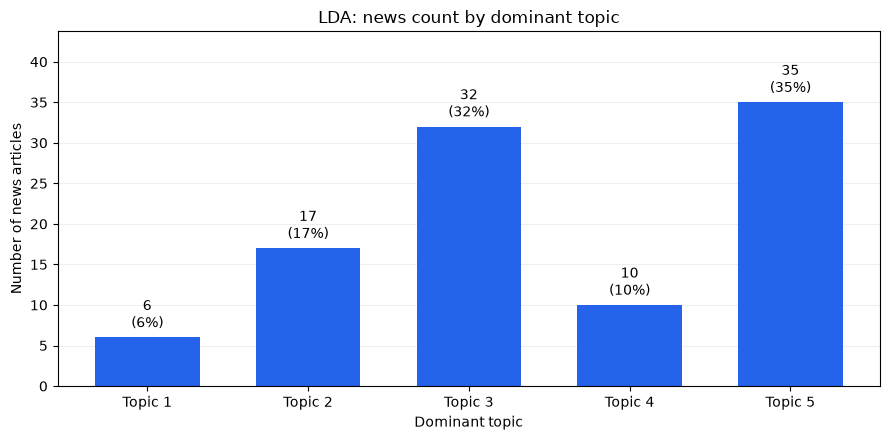

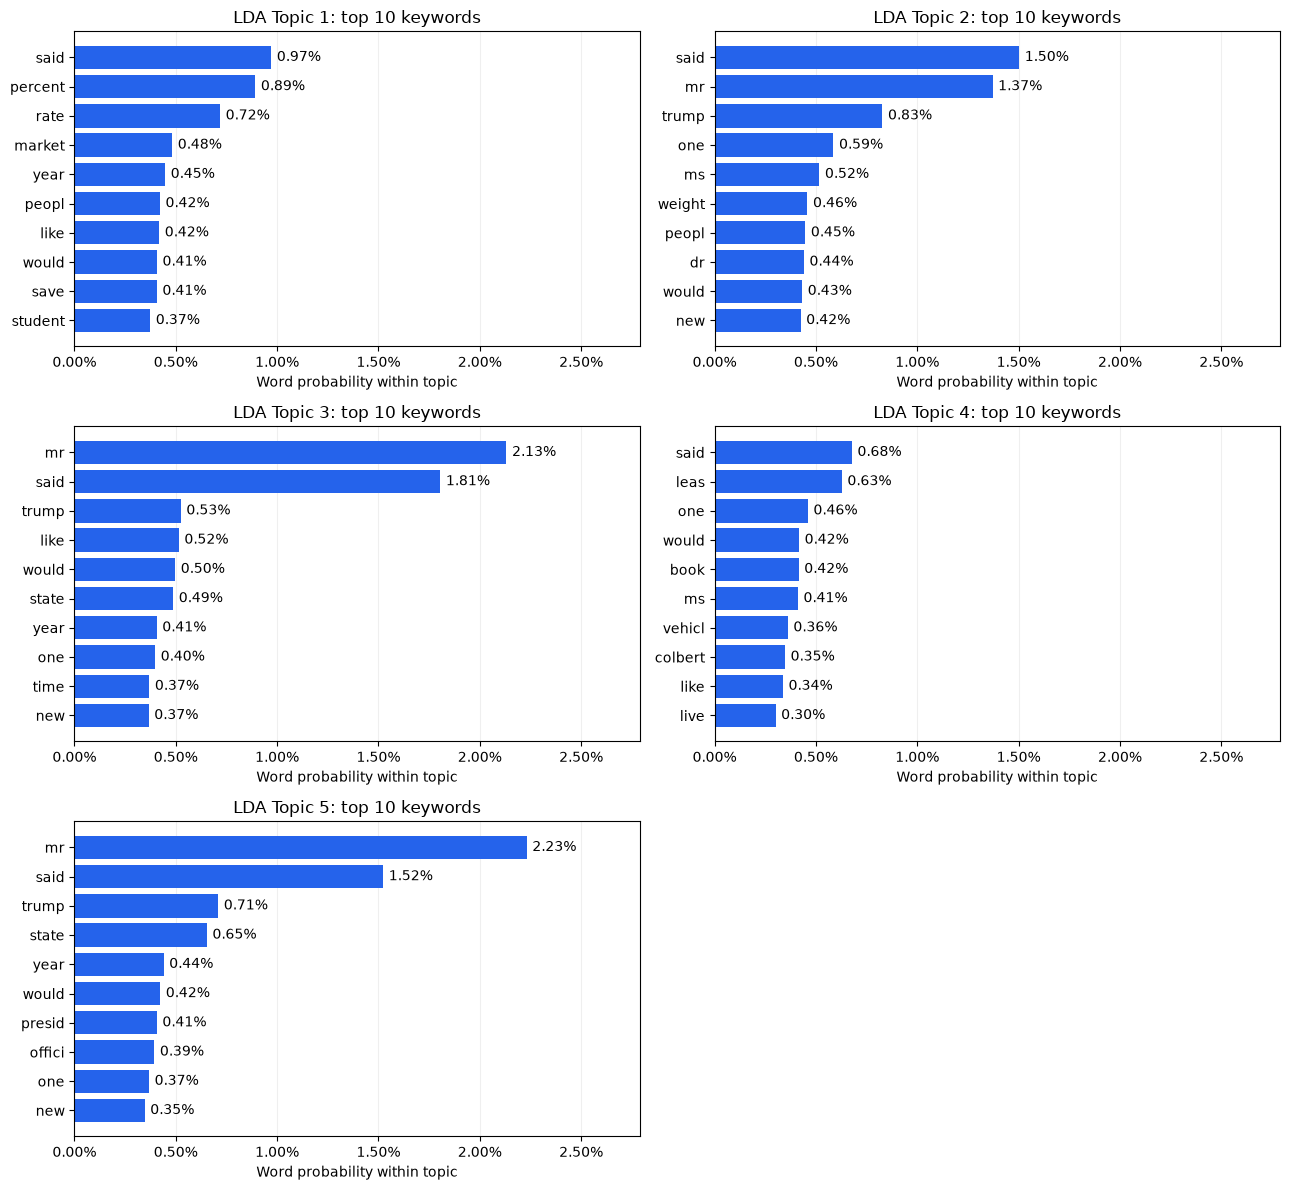

In [8]:
# 直接复用已训练的 LDA 和新闻主题概率，不重复训练。
lda_plot_topic_ids = list(range(lda_model.num_topics))
lda_plot_labels = [f"Topic {i + 1}" for i in lda_plot_topic_ids]
# 复用第 7 节统计，确保表格和图使用同一份结果。
lda_plot_counts = topic_counts
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(lda_plot_labels, lda_plot_counts.values, color=PLOT_COLOR, width=0.65)
ax.bar_label(
    bars,
    labels=[f"{count}\n({count / len(news_topic_results):.0%})" for count in lda_plot_counts],
    padding=4,
)
ax.set(
    title="LDA: news count by dominant topic",
    xlabel="Dominant topic", ylabel="Number of news articles",
    ylim=(0, max(lda_plot_counts.max() * 1.25, 1)),
)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

# 每个主题单独一张横向条形子图；最高权重的关键词排在顶部。
# 复用训练后的关键词结果，避免为绘图重复提取。
lda_plot_keywords = list(topic_keywords.values())
lda_plot_columns = 2
lda_plot_rows = (lda_model.num_topics + lda_plot_columns - 1) // lda_plot_columns
fig, axes = plt.subplots(
    lda_plot_rows, lda_plot_columns,
    figsize=(13, 4 * lda_plot_rows), squeeze=False,
)
weight_limit = max(weight for words in lda_plot_keywords for _, weight in words) * 1.25
for topic_id, words in enumerate(lda_plot_keywords):
    ax = axes.flat[topic_id]
    tokens, weights = zip(*words)
    bars = ax.barh(tokens, weights, color=PLOT_COLOR)
    ax.bar_label(bars, labels=[f"{weight:.2%}" for weight in weights], padding=4)
    ax.invert_yaxis()
    ax.set(
        title=f"LDA Topic {topic_id + 1}: top {len(words)} keywords",
        xlabel="Word probability within topic", xlim=(0, weight_limit),
    )
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

# 主题数为奇数时，隐藏最后一个空白子图。
for ax in list(axes.flat)[lda_model.num_topics:]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()


## 8. LSA：准备 TF-IDF 语料

LSA 在 Gensim 中对应 `LsiModel`，与前面的 LDA 独立训练，共用词典和词袋。TF-IDF 降低常见词的相对权重，再通过截断奇异值分解提取潜在语义方向。

接下来比较 2～10 个主题。固定语料、随机种子和每个主题的关键词数量，使用 **c_v 主题一致性**评分：观察主题关键词在原始预处理文档中是否经常共同出现，分数越高越好。它不是准确率。

LSA 的词权重有正负两端。本实验统一取绝对权重最大的 10 个词计算一致性，作为一种可复现的启发式筛选；该评分会混合两端词语，因此仍需结合带符号关键词检查可解释性。“最佳”仅指当前数据、指标和候选范围内的最佳配置。

In [9]:
# 物化为列表，以便 9 个候选模型反复读取同一份 TF-IDF 语料。
tfidf_model = TfidfModel(bow_corpus, dictionary=dictionary, normalize=True)
lsa_tfidf_corpus = list(tfidf_model[bow_corpus])
print(f"TF-IDF 文档数量：{len(lsa_tfidf_corpus)}")
print(f"TF-IDF 空文档数量：{sum(not doc for doc in lsa_tfidf_corpus)}")

def lsa_keywords(model: LsiModel, topn: int) -> list[list[str]]:
    """按词权重绝对值取每个语义方向的关键词，供统一评价使用。"""
    return [
        [word for word, _ in model.show_topic(topic_id, topn=topn)]
        for topic_id in range(model.num_topics)
    ]

lsa_models = {}
lsa_topic_word_lists = {}
for topic_count in LSA_TOPIC_COUNTS:
    model = LsiModel(
        corpus=lsa_tfidf_corpus,
        id2word=dictionary,
        num_topics=topic_count,
        random_seed=RANDOM_SEED,
    )
    lsa_models[topic_count] = model
    lsa_topic_word_lists[topic_count] = lsa_keywords(model, TOP_WORDS)

# 一次性建立共现统计，供所有候选主题复用，避免重复扫描文档。
# processes=1 使 Windows/Jupyter 下执行更稳定。
all_candidate_topics = [
    words
    for topic_count in LSA_TOPIC_COUNTS
    for words in lsa_topic_word_lists[topic_count]
]
lsa_coherence = CoherenceModel(
    topics=all_candidate_topics,
    texts=processed_documents,
    dictionary=dictionary,
    coherence="c_v",
    topn=TOP_WORDS,
    processes=1,
)
lsa_coherence.estimate_probabilities()

lsa_scores = []
for topic_count in LSA_TOPIC_COUNTS:
    lsa_coherence.topics = lsa_topic_word_lists[topic_count]
    score = float(lsa_coherence.get_coherence())
    lsa_scores.append({"主题数量": topic_count, "c_v 一致性": score})

lsa_search_results = pd.DataFrame(lsa_scores)
if not np.isfinite(lsa_search_results["c_v 一致性"]).all():
    raise ValueError("一致性评分出现非有限值，请检查语料和主题关键词。")

# 候选数按升序排列；若分数完全相同，idxmax 会优先选更少的主题。
best_row = lsa_search_results.loc[lsa_search_results["c_v 一致性"].idxmax()]
best_lsa_num_topics = int(best_row["主题数量"])
best_lsa_score = float(best_row["c_v 一致性"])
best_lsa_model = lsa_models[best_lsa_num_topics]
display(lsa_search_results.style.format({"c_v 一致性": "{:.4f}"}))

TF-IDF 文档数量：100
TF-IDF 空文档数量：0


,主题数量,c_v 一致性
0,2,0.3978
1,3,0.3559
2,4,0.4281
3,5,0.4087
4,6,0.3992
5,7,0.3954
6,8,0.3812
7,9,0.3785
8,10,0.3870


## 9. 可视化筛选结果并确定主题数量

曲线上的数字与上方评分表一致，橙色点标出最高分。根据该指标自动选择主题数；如果曲线较平或多个主题数接近，需要结合关键词人工判断，不能把微小分差当作确定优势。

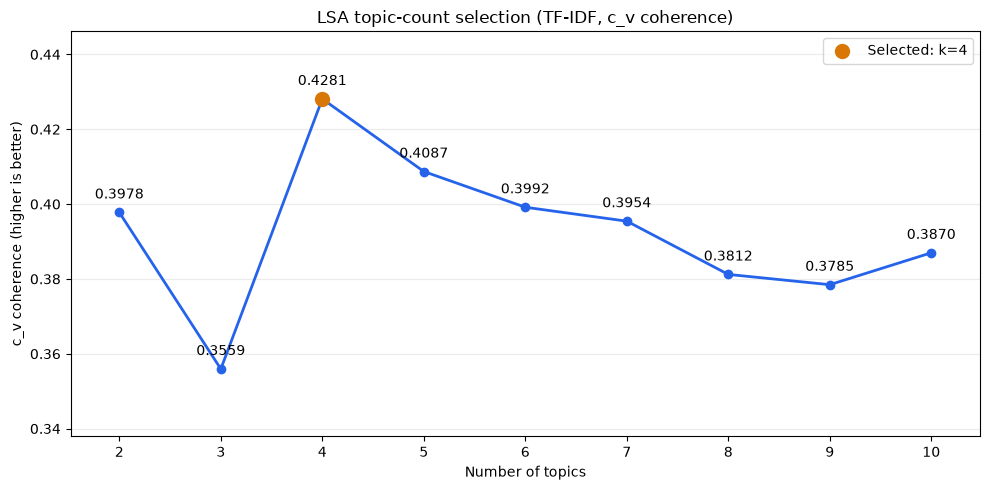

本次选择：4 个主题；c_v = 0.4281
与第二高分之差：0.0194
这是当前候选范围内的一致性最优结果，并非经过标注数据验证的准确率。


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    lsa_search_results["主题数量"],
    lsa_search_results["c_v 一致性"],
    marker="o", color=PLOT_COLOR, linewidth=2,
)
for row in lsa_search_results.to_dict("records"):
    ax.annotate(
        f'{row["c_v 一致性"]:.4f}',
        (row["主题数量"], row["c_v 一致性"]),
        xytext=(0, 10), textcoords="offset points", ha="center",
    )
ax.scatter(
    [best_lsa_num_topics], [best_lsa_score],
    s=100, color=HIGHLIGHT_COLOR, zorder=3,
    label=f"Selected: k={best_lsa_num_topics}",
)
ax.set(
    title="LSA topic-count selection (TF-IDF, c_v coherence)",
    xlabel="Number of topics",
    ylabel="c_v coherence (higher is better)",
    xticks=LSA_TOPIC_COUNTS,
)
ax.margins(x=0.06, y=0.25)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

runner_up = lsa_search_results["c_v 一致性"].nlargest(2).iloc[1]
print(f"本次选择：{best_lsa_num_topics} 个主题；c_v = {best_lsa_score:.4f}")
print(f"与第二高分之差：{best_lsa_score - runner_up:.4f}")
print("这是当前候选范围内的一致性最优结果，并非经过标注数据验证的准确率。")

## 10. 查看所选 LSA 模型

下面保留关键词权重的正负号；同一方向的两端可能表达不同语义，符号整体翻转不改变该语义方向。新闻的主题权重也有正负号，不是概率。按绝对权重选择主要语义方向仅用于展示。

In [11]:
lsa_topic_summary = pd.DataFrame([
    {
        "主题": f"LSA 主题 {topic_id + 1}",
        "关键词（词干: 带符号权重）": " | ".join(
            f"{word}: {weight:+.3f}"
            for word, weight in best_lsa_model.show_topic(topic_id, topn=TOP_WORDS)
        ),
    }
    for topic_id in range(best_lsa_num_topics)
])
with pd.option_context("display.max_colwidth", None):
    display(lsa_topic_summary)

# 用零初始化稠密矩阵，Gensim 未返回的稀疏权重自然保留为 0。
lsa_document_weights = np.zeros((len(lsa_tfidf_corpus), best_lsa_num_topics))
for row_id, vector in enumerate(best_lsa_model[lsa_tfidf_corpus]):
    for topic_id, weight in vector:
        lsa_document_weights[row_id, topic_id] = weight

lsa_weight_columns = [f"LSA 主题 {i + 1} 权重" for i in range(best_lsa_num_topics)]
lsa_news_results = news_processed.loc[model_document_indices, ["id", "title"]].copy()
lsa_news_results = lsa_news_results.join(pd.DataFrame(
    lsa_document_weights, index=model_document_indices, columns=lsa_weight_columns
))
# 零向量没有可解释的主要方向，避免将它误归为主题 1。
lsa_news_results["主要语义方向"] = [
    f"LSA 主题 {int(np.abs(weights).argmax()) + 1}" if np.any(weights) else "无有效方向"
    for weights in lsa_document_weights
]
with pd.option_context("display.max_colwidth", 90):
    display(lsa_news_results.head(RESULT_PREVIEW_ROWS).style.format(
        {column: "{:+.3f}" for column in lsa_weight_columns}
    ))
assert len(lsa_news_results) == len(model_document_indices)


,主题,关键词（词干: 带符号权重）
0,LSA 主题 1,trump: +0.297 | mr: +0.109 | immigr: +0.096 | republican: +0.093 | polic: +0.083 | speech: +0.080 | ryan: +0.077 | clinton: +0.074 | brief: +0.073 | ms: +0.071
1,LSA 主题 2,trump: +0.412 | ryan: +0.200 | polic: -0.190 | republican: +0.157 | speech: +0.114 | agenda: +0.112 | cruz: +0.106 | clinton: +0.092 | parti: +0.089 | tech: +0.087
2,LSA 主题 3,tesla: +0.298 | polic: -0.235 | model: +0.168 | rate: +0.161 | tech: +0.158 | bond: +0.123 | percent: +0.117 | milwauke: -0.115 | offic: -0.113 | compani: +0.111
3,LSA 主题 4,syria: +0.183 | russia: +0.176 | turkey: +0.175 | turkish: +0.156 | isi: +0.146 | islam: +0.135 | russian: +0.135 | bab: +0.129 | broadway: -0.114 | adnani: +0.114


,id,title,LSA 主题 1 权重,LSA 主题 2 权重,LSA 主题 3 权重,LSA 主题 4 权重,主要语义方向
0,25626,"One Weight-Loss Approach Fits All? No, Not Even Close - The New York Times",+0.115,-0.090,+0.040,-0.048,LSA 主题 1
1,19551,South Carolina Stuns Baylor to Reach the Round of Eight - The New York Times,+0.120,-0.089,-0.051,-0.086,LSA 主题 1
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Your Tuesday Evening Briefing - The New York Times",+0.308,-0.041,+0.054,+0.057,LSA 主题 1
3,18026,"His Predecessor Gone, Gambia’s New President Finally Comes Home - The New York Times",+0.118,-0.040,-0.018,+0.042,LSA 主题 1
4,21063,‘Harry Potter and the Cursed Child’ Goes From Stage to Page on Saturday at the Witching Hour - The New York Times,+0.114,-0.050,-0.039,-0.153,LSA 主题 4
5,23141,"Ted Cruz Names Carly Fiorina as His Running Mate, Seeking a Jolt - The New York Times",+0.247,+0.232,-0.033,-0.017,LSA 主题 1
6,17295,"Mar-a-Lago, the Future Winter White House and Home of the Calmer Trump - The New York Times",+0.337,+0.218,-0.040,-0.024,LSA 主题 1
7,22749,Taylor Swift Releases a Surprise Single With Zayn Malik - The New York Times,+0.112,-0.087,-0.055,-0.202,LSA 主题 4
8,20453,"Why Donald Trump, Not Paul Ryan, Is Setting the G.O.P. Agenda - The New York Times",+0.299,+0.393,-0.067,-0.002,LSA 主题 2
9,25918,Spokesman’s Death Will Have Islamic State Turning to Its ‘Deep Bench’ - The New York Times,+0.202,-0.140,+0.089,+0.446,LSA 主题 4
